In [10]:
 import math
 import numpy as np
 import matplotlib.pyplot as plt
 %matplotlib inline

In [3]:
def f(x):
  return 3*x**2 - 4*x + 5

In [4]:
f(9)

212

In [8]:
x = np.arange(-5, 5, 0.25)
y = f(x)
(x,y)

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
         55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
         25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
          7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
          4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
         13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
         37.    ,  42.1875,  47.75  ,  53.6875]))

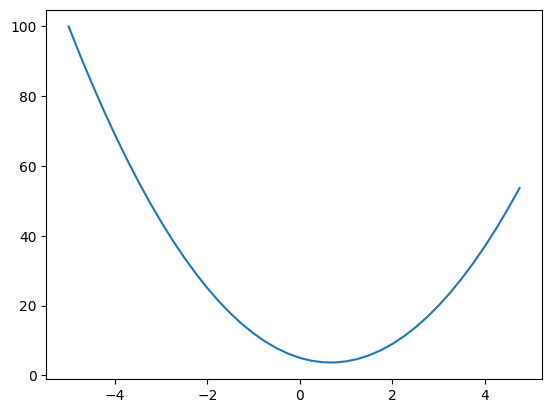

In [11]:
plt.plot(x, y)

In [16]:
h = 0.0001
x = 9
(f(x+h) - f(x))/h

50.000299999624076

In [17]:
h = 0.0001
x = -9
(f(x+h) - f(x))/h

-57.99969999998211

In [18]:
h = 0.0001
x = 2/3
(f(x+h) - f(x))/h

0.0002999999981767587

In [21]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [22]:
h = 0.001

# input
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2-d1)/h)


d1 4.0
d2 3.997
slop -3.0000000000001137


In [24]:
h = 0.001

# input
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2-d1)/h)

d1 4.0
d2 4.002
slop 1.9999999999997797


In [25]:
h = 0.001

# input
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2-d1)/h)

d1 4.0
d2 4.0009999999999994
slop 0.9999999999994458


In [26]:
class Value:
  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data = {self.data})"

In [27]:
a = Value(2.0)
a

Value(data = 2.0)

In [28]:
a = Value(2.0)
b = Value(3.0)

a+b

TypeError: unsupported operand type(s) for +: 'Value' and 'Value'

In [35]:
class Value:
  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data)
    return out

In [36]:
a = Value(2.0)
b = Value(3.0)

a+b
# a.__add__(b)

Value(data = 5.0)

In [37]:
a*b

TypeError: unsupported operand type(s) for *: 'Value' and 'Value'

In [38]:
class Value:
  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data)
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data)
    return out

In [41]:
a = Value(2.0)
b = Value(3.0)
c = Value(-4.0)
a*b + c
# a.__mul__(b).__add__(c)

Value(data = 2.0)

In [42]:
# We need to keep a track of what values produce what other values

In [43]:
class Value:
  def __init__(self, data, _children = ()):
    self.data = data
    self._prev = set(_children)

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other))
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other))
    return out

In [46]:
a = Value(2.0)
b = Value(3.0)
c = Value(-4.0)
d = a*b + c
d
# a.__mul__(b).__add__(c)

Value(data = 2.0)

In [47]:
d._prev

{Value(data = -4.0), Value(data = 6.0)}

In [48]:
# Now we know the children of evry single value but we dont know which operation  created that value

In [49]:
class Value:
  def __init__(self, data, _children = (), _op = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

In [50]:
a = Value(2.0)
b = Value(3.0)
c = Value(-4.0)
d = a*b + c
d
# a.__mul__(b).__add__(c)

Value(data = 2.0)

In [51]:
d._prev

{Value(data = -4.0), Value(data = 6.0)}

In [52]:
d._op

'+'

In [53]:
c._op

''

In [54]:
# Now we want to visualize this expression

In [55]:
# Copied code and changed it slighly (added ._op)

In [75]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [66]:
# adding label to the graph

In [67]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

In [72]:
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(-4.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data = -4.0)

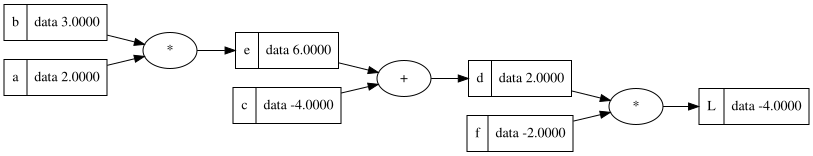

In [73]:
draw_dot(L)

In [74]:
# Now lets create a d erivative

In [76]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

In [77]:
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(-4.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data = -4.0)

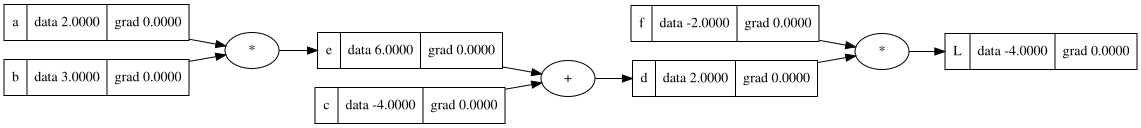

In [78]:
draw_dot(L)

In [80]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.7, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2+w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

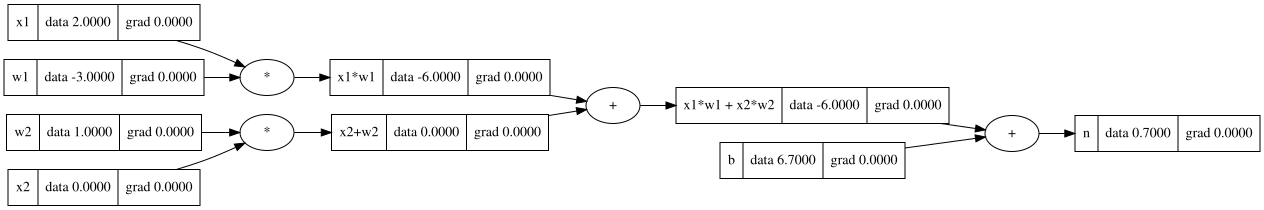

In [81]:
draw_dot(n)

In [87]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")
    return out

In [115]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

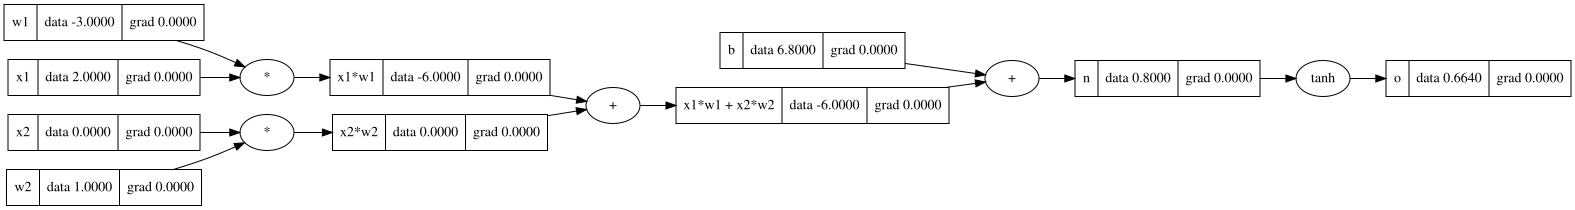

In [116]:
draw_dot(o)

In [118]:
o.grad = 1

In [119]:
# n.grad = do/dn = dtanh(n)/n = 1 - tanh(n)**2
n.grad = 1 - (o.data)**2
n.grad

0.5590551677322441

In [120]:
# n = x1w1_x2w2 + b
# add operator is ther so grad will pass on
# thus
b.grad = n.grad
x1w1_x2w2.grad = n.grad

In [121]:
# again add operator for
# x1w1_x2w2 = x1w1 + x2w2
x1w1.grad = x1w1_x2w2.grad
x2w2.grad = x1w1_x2w2.grad

In [122]:
# mul operator thus
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

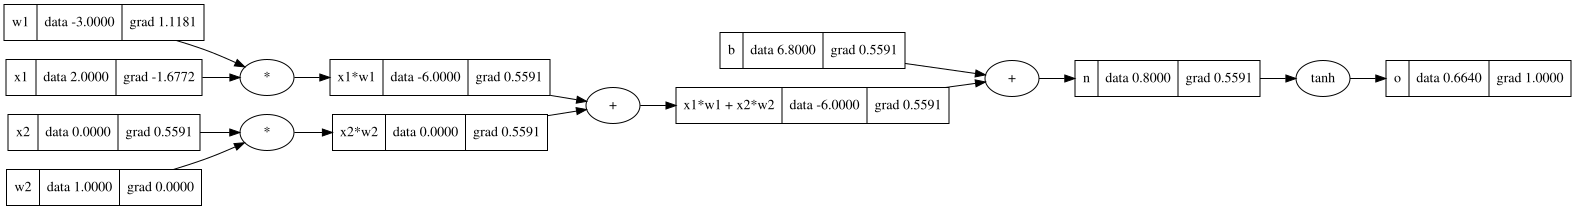

In [123]:
draw_dot(o)

In [124]:
# calculating the grad

In [125]:
from ast import Lambda
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad = (1 - t**2) * out.grad

    out._backward = _backward
    return out

In [126]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

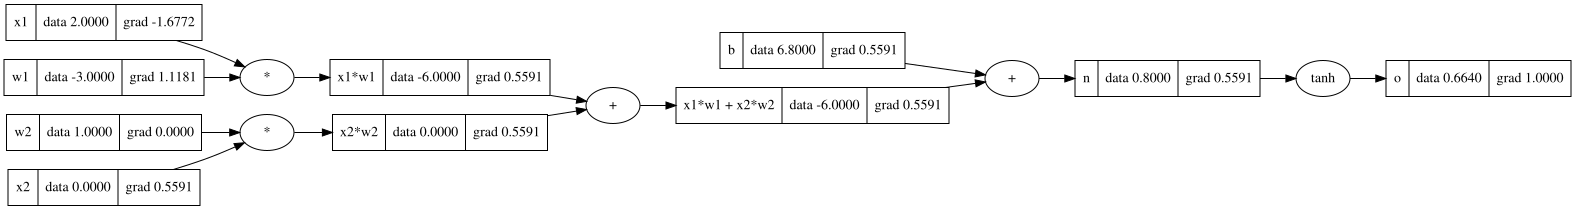

In [141]:
draw_dot(o)

In [128]:
o.grad = 1.0

In [132]:
o._backward()

In [134]:
n._backward()

In [136]:
x1w1_x2w2._backward()

In [138]:
x1w1._backward()
x2w2._backward()

In [140]:
b._backward()

In [142]:
# Above we are calling ._backward() manually we have to  make it call automatic and in the particulal order as we had called it

In [150]:
from ast import Lambda
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad = (1 - t**2) * out.grad

    out._backward = _backward
    return out

  # Tropological graph
  def backward(self):
    topo = []
    visited = set()

    def build_topo(x):
      if x not in visited:
        visited.add(x)
        for child in x._prev:
          build_topo(child)
        topo.append(x)

    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [147]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

In [148]:
o.backward()

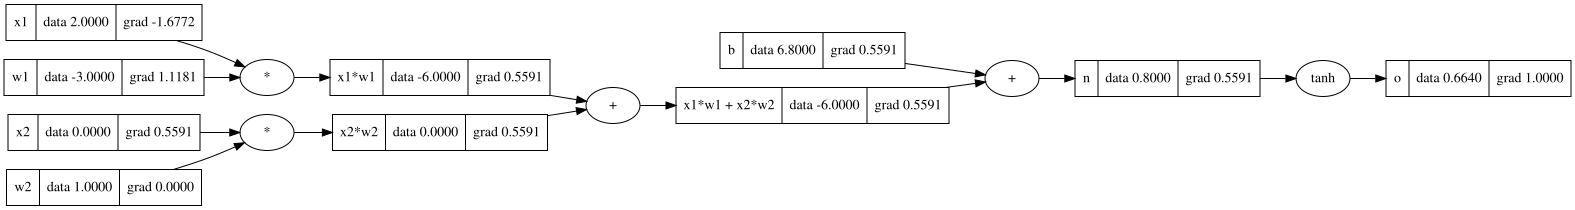

In [149]:
draw_dot(o)